# Outlier / Noise Detection and Similarity-Dissimilarity Analysis
**Pipeline step 5 of the Big Data on Cloud modular assignment** (UCI Online Retail).

Input: the *current* table produced by the CDC job (`data/cdc/current`, same data Athena queries and Redshift loads) and the rows rejected by Glue (`data/processed/rejected`, used only to find cancellations).

* **Part A** - outlier and noise detection (Tukey IQR rule)
* **Part B** - similarity / dissimilarity: Jaccard (customers), cosine (products), Euclidean on standardised RFM (customers)

All numbers shown below are computed by this notebook; nothing is typed in by hand.

In [ ]:
import json, re, warnings
from pathlib import Path
import numpy as np, pandas as pd
import scipy.sparse as sp
from scipy.spatial.distance import cdist, jaccard as scipy_jaccard
from scipy.stats import spearmanr
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
import matplotlib
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)

ROOT = Path("..")                       # notebook lives in notebooks/
FIG = ROOT / "reports/figures"; RES = ROOT / "reports/results"
FIG.mkdir(parents=True, exist_ok=True); RES.mkdir(parents=True, exist_ok=True)
results = {}                            # collected and saved at the end

sales = pd.read_parquet(ROOT / "data/cdc/current")
for c in ["unit_price", "line_total"]:
    sales[c] = sales[c].astype(float)
print(sales.shape); sales.head()

(520962, 10)


,line_id,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,line_total
0,536370-0001,536370,10002,INFLATABLE POLITICAL GLOBE,48,2010-12-01 08:45:00,0.85,12583.0,France,40.8
1,536370-0002,536370,21035,SET/2 RED RETROSPOT TEA TOWELS,18,2010-12-01 08:45:00,2.95,12583.0,France,53.1
2,536370-0003,536370,21724,PANDA AND BUNNIES STICKER SHEET,12,2010-12-01 08:45:00,0.85,12583.0,France,10.2
3,536370-0004,536370,21731,RED TOADSTOOL LED NIGHT LIGHT,24,2010-12-01 08:45:00,1.65,12583.0,France,39.6
4,536370-0005,536370,21791,VINTAGE HEADS AND TAILS CARD GAME,24,2010-12-01 08:45:00,1.25,12583.0,France,30.0


## Part A - Outlier and noise detection
### A1. Method
Feature choice (from the data inspection): **Quantity**, **UnitPrice** and **line_total** per transaction line, plus **customer spend** and **purchase frequency** per customer.

**Rule: Tukey's IQR fences.** A value is an *outlier* if it is below `Q1 - 1.5*IQR` or above `Q3 + 1.5*IQR`, and *extreme* with `3*IQR`. All three line-level features are strongly right-skewed (they span several orders of magnitude), so the fences are computed on the **log10 scale**; the raw-scale result is shown for comparison.

In [2]:
def tukey(s, k=1.5, log=True):
    x = np.log10(s) if log else s
    q1, q3 = x.quantile([.25, .75]); iqr = q3 - q1
    lo, hi = q1 - k*iqr, q3 + k*iqr
    flag = (x < lo) | (x > hi)
    bounds = (10**lo, 10**hi) if log else (lo, hi)
    return flag, bounds

rows = []
for feat in ["quantity", "unit_price", "line_total"]:
    for log in [False, True]:
        for k in [1.5, 3.0]:
            flag, (lo, hi) = tukey(sales[feat], k, log)
            rows.append({"feature": feat, "scale": "log10" if log else "raw", "k": k, "lower_fence": round(lo, 2),
                         "upper_fence": round(hi, 2), "outliers": int(flag.sum()), "pct": round(100*flag.mean(), 2)})
line_table = pd.DataFrame(rows); results["line_level_outlier_table"] = line_table.to_dict("records")
line_table

,feature,scale,k,lower_fence,upper_fence,outliers,pct
0,quantity,raw,1.5,-15.50,28.50,26753,5.14
1,quantity,raw,3.0,-32.00,45.00,19100,3.67
2,quantity,log10,1.5,0.02,498.83,434,0.08
3,quantity,log10,3.0,0.00,20736.00,2,0.00
4,unit_price,raw,1.5,-3.07,8.45,35635,6.84
5,unit_price,raw,3.0,-7.39,12.77,10089,1.94
6,unit_price,log10,1.5,0.21,24.80,4855,0.93
7,unit_price,log10,3.0,0.03,148.96,42,0.01
8,line_total,raw,1.5,-16.80,38.40,41053,7.88
9,line_total,raw,3.0,-37.50,59.10,26190,5.03


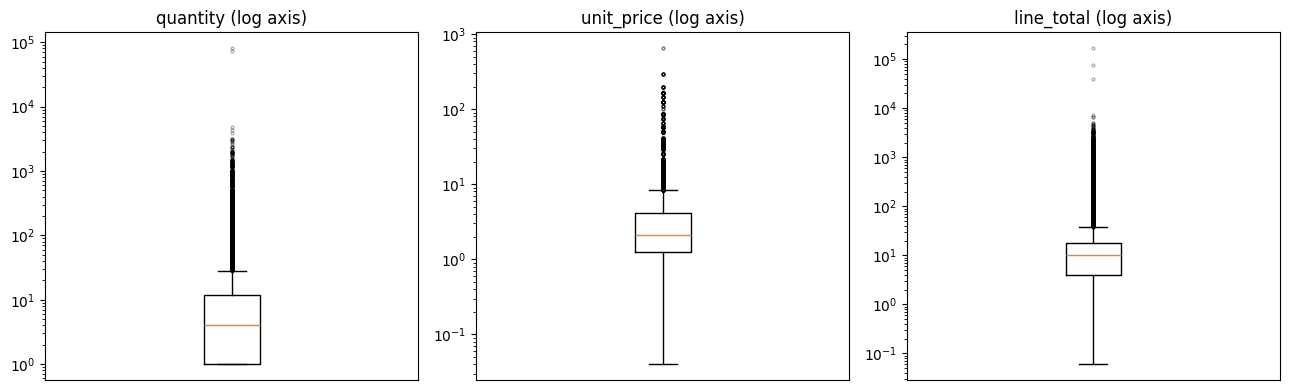

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(13, 4))
for a, feat in zip(ax, ["quantity", "unit_price", "line_total"]):
    a.boxplot(sales[feat], vert=True, showfliers=True, flierprops=dict(markersize=2, alpha=.3))
    a.set_yscale("log"); a.set_title(feat + " (log axis)"); a.set_xticks([])
plt.tight_layout(); plt.savefig(FIG / "outliers_line_boxplots.png", dpi=150); plt.show()

### A2. Is an outlier valid data or noise?
A large value is not automatically wrong - this retailer sells to wholesalers. A line is treated as **noise** only if it is (a) an extreme value (`3*IQR`, log scale, on `line_total`) **and** (b) **fully reversed by a cancellation invoice** of the same customer, product and quantity that comes later. Such an order was recorded and then cancelled, so counting it as revenue or as customer behaviour would be wrong. The cancellation rows come from the Glue `rejected` output.

In [4]:
rej = pd.read_parquet(ROOT / "data/processed/rejected")
cancel = rej[(rej.reject_reason == "cancellation_or_adjustment") & rej.invoice_no.str.startswith("C") & rej.customer_id.notna()]
cancel = cancel.assign(rev_qty=-cancel.quantity)[["customer_id", "stock_code", "rev_qty", "invoice_date"]].rename(columns={"invoice_date": "cancel_date"})

extreme_flag, (lo, hi) = tukey(sales["line_total"], 3.0, True)
cand = sales[extreme_flag & sales.customer_id.notna()]
m = cand.merge(cancel, left_on=["customer_id", "stock_code", "quantity"], right_on=["customer_id", "stock_code", "rev_qty"])
m = m[m.cancel_date >= m.invoice_date].drop_duplicates("line_id")
noise = m[["line_id", "invoice_no", "customer_id", "stock_code", "description", "quantity", "unit_price", "line_total", "invoice_date", "cancel_date"]]

print(f"extreme line_total lines (3*IQR, log): {int(extreme_flag.sum()):,}  (fence > {hi:,.2f})")
print(f"  of which fully reversed by a later cancellation (= noise): {len(noise)}  worth {noise.line_total.sum():,.2f}")
results["extreme_lines"] = int(extreme_flag.sum()); results["noise_lines"] = len(noise); results["noise_value"] = float(noise.line_total.sum())
noise.sort_values("line_total", ascending=False).head(10)

extreme line_total lines (3*IQR, log): 136  (fence > 1,654.62)
  of which fully reversed by a later cancellation (= noise): 10  worth 311,623.96


,line_id,invoice_no,customer_id,stock_code,description,quantity,unit_price,line_total,invoice_date,cancel_date
17,581483-0001,581483,16446.0,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,168469.60,2011-12-09 09:15:00,2011-12-09 09:27:00
0,541431-0001,541431,12346.0,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,77183.60,2011-01-18 10:01:00,2011-01-18 10:17:00
6,556444-0001,556444,15098.0,22502,PICNIC BASKET WICKER 60 PIECES,60,649.50,38970.00,2011-06-10 15:28:00,2011-06-10 15:39:00
1,540815-0001,540815,15749.0,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40,2011-01-11 12:55:00,2011-04-18 13:08:00
3,540815-0003,540815,15749.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,1930,2.55,4921.50,2011-01-11 12:55:00,2011-04-18 13:08:00
5,540818-0002,540818,15749.0,48185,DOORMAT FAIRY CAKE,670,6.75,4522.50,2011-01-11 12:57:00,2011-04-18 13:08:00
4,567423-0008,567423,17450.0,23113,PANTRY CHOPPING BOARD,756,5.06,3825.36,2011-09-20 11:05:00,2011-09-21 09:16:00
2,540815-0002,540815,15749.0,21175,GIN + TONIC DIET METAL SIGN,2000,1.85,3700.00,2011-01-11 12:55:00,2011-04-18 13:08:00
13,570094-0003,570094,16029.0,22273,FELTCRAFT DOLL MOLLY,720,2.55,1836.00,2011-10-07 11:56:00,2011-10-11 11:10:00
11,570097-0005,570097,16029.0,22273,FELTCRAFT DOLL MOLLY,720,2.30,1656.00,2011-10-07 12:05:00,2011-10-11 11:10:00


In [5]:
noise.to_csv(RES / "noise_lines.csv", index=False)
noise_ids = set(noise.line_id)
sales_valid = sales[~sales.line_id.isin(noise_ids)]
print("Revenue before / after removing noise lines:", f"{sales.line_total.sum():,.2f} / {sales_valid.line_total.sum():,.2f}")
results["revenue_before"] = float(sales.line_total.sum()); results["revenue_after_noise_removed"] = float(sales_valid.line_total.sum())

Revenue before / after removing noise lines: 10,231,034.78 / 9,919,410.82


### A3. Customer-level outliers (spend and purchase frequency)

In [6]:
valid_c = sales_valid[sales_valid.customer_id.notna()].copy()
snapshot = valid_c.invoice_date.max().normalize() + pd.Timedelta(days=1)
cust = valid_c.groupby("customer_id").agg(frequency=("invoice_no", "nunique"), monetary=("line_total", "sum"),
                                          last_purchase=("invoice_date", "max"), n_products=("stock_code", "nunique"))
cust["recency_days"] = (snapshot - cust.last_purchase).dt.days
print("customers:", len(cust))

rows = []
for feat in ["monetary", "frequency"]:
    flag, (lo, hi) = tukey(cust[feat], 1.5, True)
    cust[f"{feat}_outlier"] = flag
    high = int((cust[feat] > hi).sum()); low = int((cust[feat] < lo).sum())
    rows.append({"feature": feat, "lower_fence": round(lo, 2), "upper_fence": round(hi, 2), "high_outliers": high, "low_outliers": low,
                 "pct": round(100*flag.mean(), 2)})
cust_table = pd.DataFrame(rows); results["customer_outlier_table"] = cust_table.to_dict("records")
hi_cust = cust[cust.monetary_outlier & (cust.monetary > cust.monetary.median())]
results["high_spend_customers_share_of_revenue_pct"] = round(100*hi_cust.monetary.sum()/cust.monetary.sum(), 2)
print(cust_table.to_string(index=False))
print(f"high-spend outlier customers = {len(hi_cust)} = {100*len(hi_cust)/len(cust):.2f}% of customers, {results['high_spend_customers_share_of_revenue_pct']}% of identified-customer revenue")
cust.sort_values("monetary", ascending=False).head(8)

customers: 4333
  feature  lower_fence  upper_fence  high_outliers  low_outliers  pct
 monetary        24.31     20232.68             38            12 1.15
frequency         0.09        55.90             12             0 0.28
high-spend outlier customers = 38 = 0.88% of customers, 28.98% of identified-customer revenue


,frequency,monetary,last_purchase,n_products,recency_days,monetary_outlier,frequency_outlier
customer_id,,,,,,,
14646.0,72,277989.04,2011-12-08 12:12:00,699,1,True,True
18102.0,60,259666.08,2011-12-09 11:50:00,150,0,True,True
17450.0,46,190463.71,2011-12-01 13:29:00,124,8,True,False
14911.0,198,135914.43,2011-12-08 15:54:00,1783,1,True,True
12415.0,20,123030.15,2011-11-15 14:22:00,438,24,True,False
14156.0,54,116070.32,2011-11-30 10:54:00,711,9,True,False
17511.0,31,90931.64,2011-12-07 10:12:00,452,2,True,False
16029.0,62,69216.09,2011-11-01 10:27:00,43,38,True,True


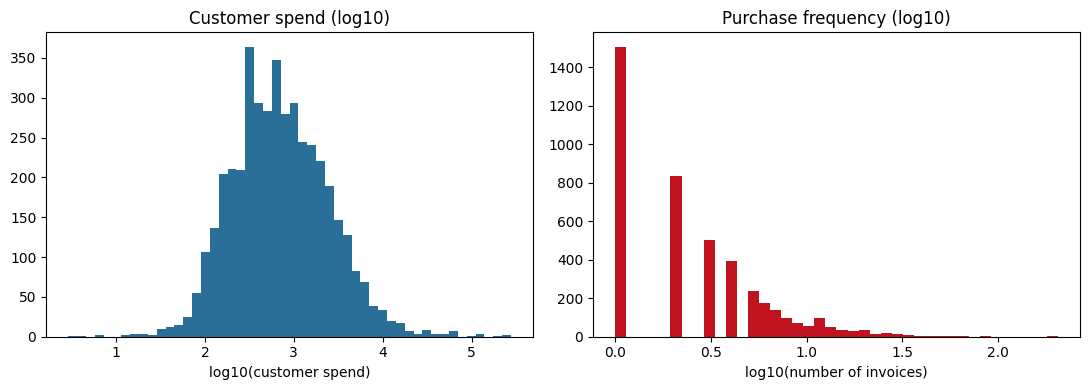

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(np.log10(cust.monetary), bins=50, color="#2a6f97"); ax[0].set_xlabel("log10(customer spend)"); ax[0].set_title("Customer spend (log10)")
ax[1].hist(np.log10(cust.frequency), bins=40, color="#c1121f"); ax[1].set_xlabel("log10(number of invoices)"); ax[1].set_title("Purchase frequency (log10)")
plt.tight_layout(); plt.savefig(FIG / "outliers_customer_hist.png", dpi=150); plt.show()

### A4. Decision (what is removed, retained or treated separately)

| Feature | Method | Flagged | Decision | Reason |
|---|---|---|---|---|
| `quantity` (line) | Tukey, log10, 1.5 x IQR (fence 0.02 - 498.83) | 434 lines (0.08%) | **Retained** | Bulk orders are normal for wholesalers. |
| `quantity` (line) | Tukey, log10, 3 x IQR | 2 lines | **Noise - excluded from value/customer analysis** | They are the 80,995-unit and 74,215-unit orders, each cancelled by a matching `C` invoice (minutes later). |
| `unit_price` (line) | Tukey, log10, 1.5 x IQR (upper fence 24.80) | 4,855 lines (0.93%) | **Retained** | Genuine expensive catalogue items (e.g. a 60-piece picnic basket at 649.50). |
| `line_total` (line) | Tukey, log10, 1.5 x IQR (upper fence 171.13) | 7,900 lines (1.52%) | **Retained, flagged** | Large but valid wholesale lines. |
| `line_total` (line) | Tukey, log10, 3 x IQR (upper fence 1,654.62) | 136 lines (0.03%); **10 fully reversed by a later cancellation** | **10 = noise, excluded from value/customer analysis; the other 126 retained** | A cancelled order is not real revenue (10 lines worth 311,623.96 = 3.05% of revenue). |
| customer spend | Tukey, log10, 1.5 x IQR | 38 high (0.88% of customers), 12 low | **Retained, treated separately as a high-value (wholesale/VIP) segment** | They generate 28.98% of identified-customer revenue; removing them would delete the most valuable customers. |
| customer frequency | Tukey, log10, 1.5 x IQR | 12 high, 0 low | **Retained** | Very frequent buyers are valid. |

**Why log scale?** On the raw scale the same rule flags 5.14% of quantities, 6.84% of prices and 7.88% of line totals, which are ordinary values for a business whose values span orders of magnitude. The log-scale fences isolate the genuinely unusual values.

**What "excluded" means.** The 10 noise lines are removed only from the monetary / customer-level calculations in this notebook (revenue, RFM, customer similarity). They stay in the warehouse (Athena / Redshift) and in the Apriori baskets, because the items really were ordered together and Apriori only uses presence of an item, not its quantity. The list is saved in `reports/results/noise_lines.csv`.

---
## Part B - Similarity / dissimilarity
| Entities compared | Representation | Measure | Why |
|---|---|---|---|
| **Customers** | binary vector over products (bought / not bought) | **Jaccard similarity** (dissimilarity = 1 - Jaccard) | Data is asymmetric binary: two customers *not* buying a product says nothing about them, and Jaccard ignores those shared zeros. |
| **Products** | binary vector over transactions (appears / does not appear) | **Cosine similarity** | Compares co-occurrence patterns and corrects for very different product popularity (vector length). |
| **Customers** | standardised log-RFM numeric vector | **Euclidean distance** | Numeric features on a common scale; a classic dissimilarity for behavioural profiles. |

### B1. Customers - Jaccard on purchased-product sets
Only customers with **at least 10 distinct products** are compared (tiny baskets would give meaningless 0/1 scores). Noise lines from Part A are excluded.

In [8]:
MIN_PRODUCTS = 10
cp = valid_c[["customer_id", "stock_code"]].drop_duplicates()
sizes = cp.groupby("customer_id").stock_code.nunique()
keep_c = sizes[sizes >= MIN_PRODUCTS].index
cp = cp[cp.customer_id.isin(keep_c)]
c_idx = {c: i for i, c in enumerate(sorted(keep_c))}; p_idx = {p: i for i, p in enumerate(sorted(cp.stock_code.unique()))}
X = sp.csr_matrix((np.ones(len(cp)), ([c_idx[c] for c in cp.customer_id], [p_idx[p] for p in cp.stock_code])), shape=(len(c_idx), len(p_idx)))
print("customers compared:", X.shape[0], "| products:", X.shape[1])

inter = (X @ X.T).toarray()                       # |A and B|
n_items = np.asarray(X.sum(axis=1)).ravel()       # |A|
union = n_items[:, None] + n_items[None, :] - inter
J = inter / union                                 # Jaccard similarity
np.fill_diagonal(J, np.nan)
cust_ids = np.array(sorted(keep_c))

iu = np.triu_indices(len(cust_ids), 1); vals = J[iu]
results["jaccard"] = {"customers": int(len(cust_ids)), "pairs": int(len(vals)), "mean": float(vals.mean()), "median": float(np.median(vals)),
                      "pct_pairs_zero_overlap": float(100*(vals == 0).mean()), "max": float(vals.max()), "p99": float(np.quantile(vals, .99))}
print(json.dumps(results["jaccard"], indent=2))

customers compared: 3698 | products: 3650


{
  "customers": 3698,
  "pairs": 6835753,
  "mean": 0.019214571760443947,
  "median": 0.013333333333333334,
  "pct_pairs_zero_overlap": 33.58262067105116,
  "max": 1.0,
  "p99": 0.09722222222222222
}


In [9]:
# Validation: our matrix-based Jaccard must equal scipy's definition (1 - scipy jaccard distance) on random pairs
rng = np.random.default_rng(0); Xd = X.toarray().astype(bool)
for _ in range(200):
    i, j = rng.choice(len(cust_ids), 2, replace=False)
    assert np.isclose(J[i, j], 1 - scipy_jaccard(Xd[i], Xd[j]))
print("Jaccard matches scipy on 200 random pairs")

top = np.argsort(vals)[::-1][:10]
pairs = pd.DataFrame({"customer_a": cust_ids[iu[0][top]], "customer_b": cust_ids[iu[1][top]], "jaccard_similarity": vals[top].round(3),
                      "jaccard_dissimilarity": (1 - vals[top]).round(3), "shared_products": inter[iu][top].astype(int),
                      "products_a": n_items[iu[0][top]].astype(int), "products_b": n_items[iu[1][top]].astype(int)})
results["top_similar_customer_pairs"] = pairs.to_dict("records")
pairs

Jaccard matches scipy on 200 random pairs


,customer_a,customer_b,jaccard_similarity,jaccard_dissimilarity,shared_products,products_a,products_b
0,14567.0,14937.0,1.000,0.000,33,33,33
1,14567.0,17173.0,0.816,0.184,31,33,36
2,14937.0,17173.0,0.816,0.184,31,33,36
3,14937.0,18167.0,0.727,0.273,24,33,24
4,14567.0,18167.0,0.727,0.273,24,33,24
5,17173.0,18167.0,0.667,0.333,24,36,24
6,17053.0,18167.0,0.542,0.458,13,13,24
7,12748.0,14911.0,0.476,0.524,1143,1762,1783
8,13242.0,15769.0,0.462,0.538,12,12,26
9,13177.0,14567.0,0.429,0.571,15,17,33


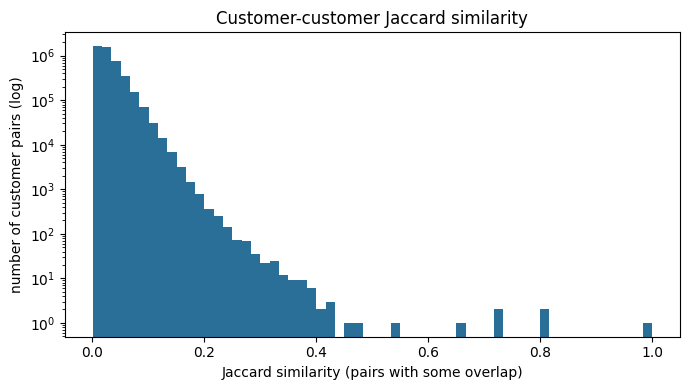

reference customer: 14646.0 products: 699


,customer_id,jaccard_similarity,shared_products
0,12415.0,0.291,256
1,13089.0,0.275,288
2,14911.0,0.273,533
3,14096.0,0.262,377
4,12748.0,0.259,507


In [10]:
plt.figure(figsize=(7, 4)); plt.hist(vals[vals > 0], bins=60, color="#2a6f97"); plt.yscale("log")
plt.xlabel("Jaccard similarity (pairs with some overlap)"); plt.ylabel("number of customer pairs (log)"); plt.title("Customer-customer Jaccard similarity")
plt.tight_layout(); plt.savefig(FIG / "similarity_jaccard_hist.png", dpi=150); plt.show()

# Example: the 5 customers most similar to the highest-spending customer in the compared set
best = cust.loc[cust.index.isin(cust_ids)].monetary.idxmax(); bi = c_idx[best]
order = np.argsort(np.nan_to_num(J[bi], nan=-1))[::-1][:5]
nn = pd.DataFrame({"customer_id": cust_ids[order], "jaccard_similarity": J[bi, order].round(3), "shared_products": inter[bi, order].astype(int)})
print("reference customer:", best, "products:", int(n_items[bi])); results["nn_reference_customer"] = int(best); nn

### B2. Products - cosine similarity on transaction vectors
Products that appear in at least as many baskets as the Apriori support threshold (1% of baskets with 2+ items) are compared, so the two analyses are directly comparable.

In [11]:
bk = sales[["invoice_no", "stock_code"]].drop_duplicates()
bk = bk[bk.groupby("invoice_no").stock_code.transform("nunique") >= 2]
n_b = bk.invoice_no.nunique(); cnt = bk.stock_code.value_counts()
keep_p = cnt[cnt >= 0.01 * n_b].index
bk = bk[bk.stock_code.isin(keep_p)]
b_idx = {b: i for i, b in enumerate(bk.invoice_no.unique())}; pr = sorted(keep_p); pr_idx = {p: i for i, p in enumerate(pr)}
P = sp.csr_matrix((np.ones(len(bk)), ([pr_idx[p] for p in bk.stock_code], [b_idx[b] for b in bk.invoice_no])), shape=(len(pr), len(b_idx)))
S = cosine_similarity(P)                         # product x product
inter_p = (P @ P.T).toarray(); cn = np.asarray(P.sum(axis=1)).ravel()
S_manual = inter_p / np.sqrt(np.outer(cn, cn))   # cosine for binary vectors = |A and B| / sqrt(|A||B|)
assert np.allclose(S, S_manual); print("cosine matches manual formula; products compared:", len(pr), "baskets:", len(b_idx))

names = (sales.groupby(["stock_code", "description"]).size().reset_index(name="n").sort_values("n", ascending=False).drop_duplicates("stock_code").set_index("stock_code").description)
np.fill_diagonal(S, np.nan)
rows = []
for code_ in cnt.index[:5]:
    i = pr_idx[code_]; o = np.argsort(np.nan_to_num(S[i], nan=-1))[::-1][:3]
    for r, j in enumerate(o, 1):
        rows.append({"product": f"{names[code_]} [{code_}]", "rank": r, "most_similar_product": f"{names[pr[j]]} [{pr[j]}]", "cosine": round(S[i, j], 3)})
prod_nn = pd.DataFrame(rows); results["product_neighbours"] = prod_nn.to_dict("records")
prod_nn

cosine matches manual formula; products compared: 896 baskets: 18029


,product,rank,most_similar_product,cosine
0,WHITE HANGING HEART T-LIGHT HOLDER [85123A],1,RED HANGING HEART T-LIGHT HOLDER [21733],0.384
1,WHITE HANGING HEART T-LIGHT HOLDER [85123A],2,CANDLEHOLDER PINK HANGING HEART [22804],0.328
2,WHITE HANGING HEART T-LIGHT HOLDER [85123A],3,WOODEN PICTURE FRAME WHITE FINISH [82482],0.260
3,JUMBO BAG RED RETROSPOT [85099B],1,JUMBO BAG PINK POLKADOT [22386],0.519
4,JUMBO BAG RED RETROSPOT [85099B],2,JUMBO STORAGE BAG SUKI [21931],0.456
5,JUMBO BAG RED RETROSPOT [85099B],3,JUMBO SHOPPER VINTAGE RED PAISLEY [22411],0.433
6,REGENCY CAKESTAND 3 TIER [22423],1,ROSES REGENCY TEACUP AND SAUCER [22699],0.361
7,REGENCY CAKESTAND 3 TIER [22423],2,GREEN REGENCY TEACUP AND SAUCER [22697],0.357
8,REGENCY CAKESTAND 3 TIER [22423],3,PINK REGENCY TEACUP AND SAUCER [22698],0.321
9,PARTY BUNTING [47566],1,SPOTTY BUNTING [23298],0.347


In [12]:
# Link to Apriori: do high-lift rules connect products with high cosine similarity?
r1 = pd.read_csv(RES / "association_rules_1to1.csv")
get = lambda s: re.search(r"\[([^\]]+)\]$", s).group(1)
r1["a"] = r1.antecedent.map(get); r1["c"] = r1.consequent.map(get)
r1 = r1[r1.a.isin(pr_idx) & r1.c.isin(pr_idx)]
r1["cosine"] = [S[pr_idx[a], pr_idx[c]] for a, c in zip(r1.a, r1.c)]
rho, p = spearmanr(r1.lift, r1.cosine)
results["lift_vs_cosine_spearman"] = {"rho": float(rho), "p": float(p), "n_rules": int(len(r1))}
print(f"Spearman correlation between rule lift and product cosine similarity: rho={rho:.3f} (n={len(r1)} rules)")

Spearman correlation between rule lift and product cosine similarity: rho=0.870 (n=287 rules)


### B3. Customers - Euclidean dissimilarity on standardised RFM
Features: `log10(monetary)`, `log10(frequency)`, `recency_days` (days since last purchase). Standardised to mean 0 / std 1 so no feature dominates.

In [13]:
F = pd.DataFrame({"log_monetary": np.log10(cust.monetary), "log_frequency": np.log10(cust.frequency), "recency_days": cust.recency_days}, index=cust.index)
Z = StandardScaler().fit_transform(F)
D = cdist(Z, Z, "euclidean")
# validation against the textbook formula for random pairs
for _ in range(200):
    i, j = rng.choice(len(Z), 2, replace=False)
    assert np.isclose(D[i, j], np.sqrt(((Z[i] - Z[j])**2).sum()))
print("Euclidean matches the formula on 200 random pairs; customers:", len(Z))
ids = cust.index.to_numpy(); ref = cust.monetary.idxmax(); ri = list(ids).index(ref)
order = np.argsort(D[ri]); near, far = order[1:4], order[-3:][::-1]
show = lambda idx, lab: pd.DataFrame({"role": lab, "customer_id": ids[idx], "euclidean_distance": D[ri, idx].round(3), **F.iloc[idx].round(2).to_dict("list")})
rfm_cmp = pd.concat([show([ri], "reference (top spender)"), show(near, "most similar"), show(far, "most dissimilar")], ignore_index=True)
results["rfm_reference"] = int(ref); results["rfm_comparison"] = rfm_cmp.to_dict("records")
rfm_cmp

Euclidean matches the formula on 200 random pairs; customers: 4333


,role,customer_id,euclidean_distance,log_monetary,log_frequency,recency_days
0,reference (top spender),14646.0,0.000,5.44,1.86,1
1,most similar,18102.0,0.210,5.41,1.78,0
2,most similar,17450.0,0.586,5.28,1.66,8
3,most similar,14156.0,0.770,5.06,1.73,9
4,most dissimilar,16738.0,10.549,0.57,0.00,297
5,most dissimilar,16446.0,10.507,0.46,0.00,205
6,most dissimilar,16454.0,9.828,0.77,0.00,64


In [14]:
# Do customers that are close in RFM space also buy the same products (Jaccard)? Compare on customers present in both.
common = [c for c in cust_ids if c in set(ids)]
ji = np.array([c_idx[c] for c in common]); di = np.array([list(ids).index(c) for c in common])
sub = rng.choice(len(common), 400, replace=False)
a, b = np.triu_indices(len(sub), 1)
jv = J[np.ix_(ji[sub], ji[sub])][a, b]; dv = D[np.ix_(di[sub], di[sub])][a, b]
rho2, _ = spearmanr(jv, dv)
results["jaccard_vs_rfm_distance_spearman"] = float(rho2)
print(f"Spearman(Jaccard similarity, RFM Euclidean distance) on 400 random customers = {rho2:.3f}")

Spearman(Jaccard similarity, RFM Euclidean distance) on 400 random customers = -0.053


**Customers (Jaccard).** Customers share very little: mean similarity is 0.019, median 0.013 and 33.58% of the 6,835,753 customer pairs have no product in common (99th percentile 0.097). Only a handful of pairs are close. Customers 14567 and 14937 bought exactly the same 33 products (Jaccard 1.0) and customers 17173 and 18167 overlap strongly with them (0.67 - 0.82), which looks like a small group of accounts with an almost identical buying list (a hypothesis that would need business data to confirm). The pair 12748 / 14911 is different: two large buyers with about 1,750 products each share 1,143 of them (0.476), i.e. broad-range wholesalers.

**Products (cosine).** The nearest neighbours of a product are its own colour/design variants: JUMBO BAG RED RETROSPOT is closest to JUMBO BAG PINK POLKADOT (0.519), LUNCH BAG RED RETROSPOT to LUNCH BAG PINK POLKADOT (0.465) and REGENCY CAKESTAND 3 TIER to the REGENCY TEACUP AND SAUCER colours (0.32 - 0.36). Across the 287 single-item Apriori rules, cosine similarity and lift are strongly rank-correlated (Spearman 0.870), so two different methods agree on which products belong together.

**Customers (Euclidean on RFM).** The top spender 14646 (about 72 invoices, last purchase 1 day before the snapshot) is closest to 18102 (distance 0.21), another top spender, and farthest (about 10.5) from customers who bought once, spent little and have not returned for months (e.g. 16738, recency 297 days).

**Two views, two answers.** Similarity of purchase *value/behaviour* (RFM) and similarity of purchased *products* (Jaccard) are almost unrelated: the Spearman correlation on 400 random customers is -0.053. So product-based similarity is the right input for recommendations, while RFM distance is the right input for segmenting customers by value.

In [15]:
json.dump(results, open(RES / "outlier_similarity_results.json", "w"), indent=2, default=str)
print("saved", RES / "outlier_similarity_results.json")

saved ../reports/results/outlier_similarity_results.json
